# TfL Tube Strikes → Cycle Hire Usage (Data Pipeline)

This notebook builds a modelling-ready dataset for a causal ML / meta-learner analysis of:

> **How Tube strikes change cycle hire demand, and how that effect varies by time and location.**

We do four things in order:

1. **Aggregate raw journey extracts** into a station–time panel (station-hour by default).
2. **Load bike station locations** (BikePoint API dump).
3. **Fetch Tube stations + served Underground lines** (TfL StopPoint API) and build a **bike-station → Underground-line** exposure map.
4. **Expand strike events** (line-level, date ranges) and **join strike exposure** onto the station–time panel.

Outputs:
- `base_station_time.parquet` (or CSV): station_id × ts × trips (+ features you add later)
- `station_line_map.csv`: station_id × affected_line (plus nearest tube station and distance)


In [7]:
# Imports + project utilities
import pandas as pd

# Make sure tfl_utils.py is on your Python path.
# If it's in the same folder as this notebook, this will work.
from tfl_utils import (
    aggregate_from_folder_chunked,
    aggregate_one_csv_to_parquet,
    load_bike_station_locations,
    fetch_tube_stations_and_lines,
    build_station_line_map,
    expand_strikes_daily,
    attach_strikes_to_base,
    aggregate_one_file_to_parquet,
)

pd.set_option("display.max_columns", 50)


## 0) Configure paths

Edit these for your machine.

- `JOURNEY_FOLDER` should contain all the raw TfL journey CSV extracts you downloaded.
- `STRIKES_CSV` is your line-level strike table (`date_start`, `date_end`, `affected_line`).
- `BIKEPOINTS_JSON` is the JSON dump from the BikePoint API (all docking stations).


In [9]:
from pathlib import Path

# Raw journey extracts (many CSVs)
JOURNEY_FOLDER = Path(r"E:\tfl_project\data")

# Your strike events table
STRIKES_CSV = Path(r"E:\tfl_project\strikes\strikes_v2.csv")

# BikePoint station locations (downloaded JSON)
BIKEPOINTS_JSON = Path(r"E:\tfl_project\BikePoint.json")

# Where to save outputs
OUT_DIR = Path(r"E:\tfl_project\outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)


## 1) Build the station–time outcome panel

We aggregate the journey extracts into either:
- **station-hour** (recommended), or
- station-day (if you want a coarser unit).

`trips_start` counts journeys starting at station_id during that hour/day.

Notes:
- We read in chunks to avoid memory crashes.
- The extract schema changes across years; the utility detects the right columns per file.


In [4]:
from pathlib import Path

journey_dir = Path(r"E:\tfl_project\data")
out_dir = Path(r"E:\tfl_project\agg_parts_parquet")

files = sorted(list(journey_dir.rglob("*.csv")) + list(journey_dir.rglob("*.xlsx")) + list(journey_dir.rglob("*.xls")))

written = 0
skipped = 0

for f in files:
    print(f"Processing {f.name} ...")
    out = aggregate_one_file_to_parquet(
        f,
        out_dir,
        freq="h",
        side="start",
        chunksize=120_000,
        sheet_name=0,
        max_station_id=5000
        #engine="xlrd"  # safe default for xlsx
    )
    
    if out is None:
        skipped += 1
        print(f"  -> skipped (missing columns)")
    else:
        written += 1

print(f"Done. Written={written}, skipped={skipped}")

Processing 01aJourneyDataExtract10Jan16-23Jan16.csv ...
Processing 01bJourneyDataExtract24Jan16-06Feb16.csv ...
Processing 02aJourneyDataExtract07Fe16-20Feb2016.csv ...
Processing 02bJourneyDataExtract21Feb16-05Mar2016.csv ...
Processing 03JourneyDataExtract06Mar2016-31Mar2016.csv ...
Processing 04JourneyDataExtract01Apr2016-30Apr2016.csv ...
Processing 05JourneyDataExtract01May2016-17May2016.csv ...
Processing 06JourneyDataExtract18May2016-24May2016.csv ...
Processing 07JourneyDataExtract25May2016-31May2016.csv ...
Processing 08JourneyDataExtract01Jun2016-07Jun2016.csv ...
Processing 09JourneyDataExtract08Jun2016-14Jun2016.csv ...
Processing 100JourneyDataExtract07Mar2018-13Mar2018.csv ...
Processing 101JourneyDataExtract14Mar2018-20Mar2018.csv ...
Processing 102JourneyDataExtract21Mar2018-27Mar2018.csv ...
Processing 103JourneyDataExtract28Mar2018-03Apr2018.csv ...
Processing 104JourneyDataExtract04Apr2018-10Apr2018.csv ...
Processing 105JourneyDataExtract11Apr2018-17Apr2018.csv ...


In [1]:
from pathlib import Path
import pandas as pd

parts = sorted(Path(r"E:\tfl_project\agg_parts_parquet").glob("*.parquet"))

acc = None
for p in parts:
    chunk = pd.read_parquet(p)
    if acc is None:
        acc = chunk
    else:
        acc = pd.concat([acc, chunk], ignore_index=True)
        acc = acc.groupby(["station_id", "ts"], as_index=False)["trips_start"].sum()
    # occasional compaction helps on 8GB
    acc["station_id"] = acc["station_id"].astype("int32")
    acc["trips_start"] = acc["trips_start"].astype("int32")

acc = acc.sort_values(["station_id", "ts"]).reset_index(drop=True)
acc.to_parquet(r"E:\tfl_project\station_hour_base.parquet", index=False)

In [2]:
import pyarrow.parquet as pa

In [3]:
_base = pa.read_table('E:\\tfl_project\station_hour_base.parquet')
base = _base.to_pandas()
base.head()

,station_id,ts,trips_start
0,1,2016-01-10 09:00:00,4
1,1,2016-01-10 10:00:00,1
2,1,2016-01-10 11:00:00,2
3,1,2016-01-10 12:00:00,2
4,1,2016-01-10 13:00:00,2


In [4]:
base.shape

(9671772, 3)

In [5]:
print("Rows:", len(base))
print("Unique stations:", base["station_id"].nunique())
print("Time range:", base["ts"].min(), "→", base["ts"].max())


Rows: 9671772
Unique stations: 1191
Time range: 2016-01-10 00:00:00 → 2019-01-01 23:00:00


## 2) Load bike station locations

We need bike station `lat/lon` to map each bike station to nearby Tube stations.

The BikePoint JSON contains all docking stations with:
- `id` like `BikePoints_123`
- `lat`, `lon`
- `commonName`


In [10]:
bike_stations = load_bike_station_locations(BIKEPOINTS_JSON)
bike_stations.head()

,station_id,lat,lon,station_name
0,1,51.529163,-0.109970,"River Street , Clerkenwell"
1,2,51.499606,-0.197574,"Phillimore Gardens, Kensington"
2,3,51.521283,-0.084605,"Christopher Street, Liverpool Street"
3,4,51.530059,-0.120973,"St. Chad's Street, King's Cross"
4,5,51.493130,-0.156876,"Sedding Street, Sloane Square"


## 3) Fetch Tube stations + served Underground lines

We pull Tube stations from TfL StopPoint API and keep only true Underground lines.

This produces:
- `tube_stations`: station ids + lat/lon
- `tube_lines`: mapping from tube_station_id → affected_line (e.g. `central_line`)


In [11]:
tube_stations, tube_lines = fetch_tube_stations_and_lines()
tube_stations.head(), tube_lines.head()

(  tube_station_id                       tube_station_name        lat       lon
 0    0400ZZLUAMS0            Amersham Underground Station  51.674206 -0.607362
 1    0400ZZLUCAL0  Chalfont & Latimer Underground Station  51.667915 -0.560616
 2    0400ZZLUCAL1  Chalfont & Latimer Underground Station  51.668122 -0.560624
 3    0400ZZLUCSM0             Chesham Underground Station  51.705227 -0.611113
 4    2100ZZLUCXY0             Croxley Underground Station  51.647069 -0.441746,
   tube_station_id    affected_line
 0    9400ZZBPSUST    northern_line
 1    9400ZZLUACT1    district_line
 2    9400ZZLUACT2    district_line
 3    9400ZZLUACT3  piccadilly_line
 4    9400ZZLUACT4  piccadilly_line)

## 4) Build station → line exposure mapping

Definition (simple and defensible):
- A bike station is "connected" to an Underground line if it is within `radius_m` of **any** Tube station served by that line.
- If a bike station has no Tube station within radius, we can optionally map it to the nearest Tube station (`fallback_to_nearest=True`).

We then **deduplicate** to one row per `(station_id, affected_line)` using the nearest Tube station record.


In [12]:
station_line_map = build_station_line_map(
    bike_stations=bike_stations,
    tube_stations=tube_stations,
    tube_lines=tube_lines,
    radius_m=800,              # walking catchment radius
    fallback_to_nearest=True,
    dedupe_line_per_station=True,
)

station_line_map.head()

,station_id,affected_line,tube_station_id,dist_m
0,1,northern_line,9400ZZLUAGL2,404.627788
1,2,circle_line,940GZZLUHSK,368.140822
2,2,district_line,940GZZLUHSK,368.140822
3,3,central_line,HUBLST,384.899549
4,3,circle_line,HUBLST,384.899549


In [13]:
# Sanity checks: number of lines per bike station
desc = station_line_map.groupby("station_id")["affected_line"].nunique().describe()
desc

count    719.000000
mean       3.141864
std        1.938300
min        1.000000
25%        1.000000
50%        3.000000
75%        5.000000
max        8.000000
Name: affected_line, dtype: float64

## 5) Load strike events and expand to daily

Your strike table is line-level, with date ranges:
- `date_start`, `date_end`, `affected_line`

We expand into:
- one row per **date × affected_line**.


In [14]:
strike_data = pd.read_csv(STRIKES_CSV)
strike_data

,date_start,date_end,affected_line
0,07/11/18,07/11/18,central_line
1,05/10/18,05/10/18,central_line
2,26/09/18,29/09/18,piccadilly_line
3,22/08/18,24/08/18,central_line
4,12/07/18,13/07/18,central_line
5,13/04/18,13/04/18,central_line
6,07/05/17,08/05/17,northern_line
7,07/05/17,08/05/17,jubilee_line
8,21/02/17,22/02/17,central_line
9,24/12/16,25/12/16,hammersmith_city_line


In [15]:
strikes_daily = expand_strikes_daily(strike_data)
strikes_daily

e:\tfl_project\tfl_utils.py:646: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  s["date_start"] = pd.to_datetime(s["date_start"], dayfirst=True, errors="coerce")
e:\tfl_project\tfl_utils.py:647: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  s["date_end"] = pd.to_datetime(s["date_end"], dayfirst=True, errors="coerce")


,date,affected_line,strike
0,2018-11-07,central_line,1
1,2018-10-05,central_line,1
2,2018-09-26,piccadilly_line,1
3,2018-09-27,piccadilly_line,1
4,2018-09-28,piccadilly_line,1
5,2018-09-29,piccadilly_line,1
6,2018-08-22,central_line,1
7,2018-08-23,central_line,1
8,2018-08-24,central_line,1
9,2018-07-12,central_line,1


## 6) Attach strike exposure to the station–time panel

We define binary exposure:

> `strike_exposed = 1` for station `s` on day `d` if **any** line connected to station `s`
> is on strike on day `d`.

This yields a station-hour panel with an added `strike_exposed` indicator.


In [16]:
base_with_strikes = attach_strikes_to_base(
    base=base,
    strikes_daily=strikes_daily,
    station_line_map=station_line_map,
)

base_with_strikes.shape

(9671772, 4)

In [17]:
# Treatment prevalence sanity check
print("Share of station-hours treated:", base_with_strikes["strike_exposed"].mean())

daily_flag = (
    base_with_strikes.assign(date=base_with_strikes["ts"].dt.floor("D"))
    .groupby("date")["strike_exposed"]
    .max()
)
print("Number of strike days flagged in panel:", int(daily_flag.sum()))
daily_flag.value_counts()


Share of station-hours treated: 0.006584625857598793
Number of strike days flagged in panel: 20


strike_exposed
0    1068
1      20
Name: count, dtype: int64

## 7) Save outputs

For modelling, prefer Parquet (fast + compact).  
If you don't have `pyarrow` installed in your environment, install it in your `.venv`:

```powershell
python -m pip install pyarrow
```


In [18]:
# Save station_line_map (small, useful to inspect)
station_line_map.to_csv(OUT_DIR / "station_line_map.csv", index=False)

# Save modelling basefile
try:
    base_with_strikes.to_parquet(OUT_DIR / "base_station_hour.parquet", index=False)
    print("Saved:", OUT_DIR / "base_station_hour.parquet")
except Exception as e:
    print("Parquet save failed (pyarrow missing?). Falling back to CSV. Error:", e)
    base_with_strikes.to_csv(OUT_DIR / "base_station_hour.csv", index=False)
    print("Saved:", OUT_DIR / "base_station_hour.csv")


Saved: E:\tfl_project\outputs\base_station_hour.parquet


## 8) Quick visual sanity checks (optional)

These are *descriptive* checks (not causal estimates).

- Total trips over time
- Mark strike days


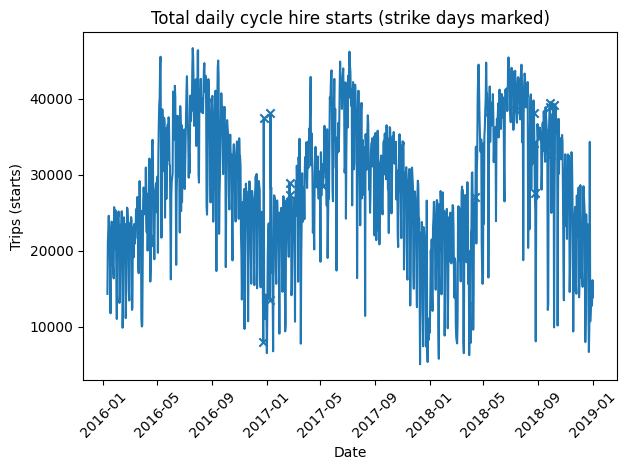

: 

In [ ]:
import matplotlib.pyplot as plt

daily_total = (
    base_with_strikes.assign(date=base_with_strikes["ts"].dt.floor("D"))
    .groupby("date", as_index=False)["trips_start"]
    .sum()
    .sort_values("date")
)

daily_strike = (
    base_with_strikes.assign(date=base_with_strikes["ts"].dt.floor("D"))
    .groupby("date", as_index=False)["strike_exposed"]
    .max()
)

daily = daily_total.merge(daily_strike, on="date", how="left").fillna({"strike_exposed": 0})

plt.figure()
plt.plot(daily["date"], daily["trips_start"])
plt.scatter(daily.loc[daily["strike_exposed"] == 1, "date"],
            daily.loc[daily["strike_exposed"] == 1, "trips_start"],
            marker="x")
plt.title("Total daily cycle hire starts (strike days marked)")
plt.xlabel("Date")
plt.ylabel("Trips (starts)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
